# Mappare la Copertura dei Siti Cellulari con una Superficie di Contorno della Perdita di Percorso

## Riepilogo Esecutivo

Un team di pianificazione RF per le telecomunicazioni disegna la **superficie di perdita di percorso** in downlink attorno a una singola macro-cella come mappa di copertura bidimensionale. Utilizzando un modello di propagazione log-distanza con shadow fading log-normale, questo notebook costruisce una griglia di misurazione di 100 punti (10 x 10 celle su un'area di servizio di 10 km x 10 km, con la torre al centro) e disegna una superficie di contorno riempita con **PROC SGPLOT HEATMAPPARM** più una scala cromatica a gradiente e linee di riferimento per la torre.

Sulla griglia eseguita la perdita di percorso va da **50.4 dB** (nel bacino luminoso presso la torre) a **90.0 dB** nell'angolo più lontano, con una media di **75.6 dB**. Classificando ogni cella in base alla sua perdita si ottengono **38 Forte, 61 Utilizzabile e 1 Debole**; l'unica cella Debole si trova a **(9.5, 9.5) km — l'angolo diagonalmente opposto alla torre — a 89.97 dB**, l'unico buco di copertura che un pianificatore segnalerebbe prima di una decisione di infill con small-cell.

> **Una nota sulla procedura.** In SAS lo strumento classico per le mappe di contorno a isolinee è `PROC GCONTOUR`. Jenner analizza GCONTOUR ed emette una spec di grafico corretta, ma il suo renderer raster non disegna ancora la geometria del contorno (l'immagine torna vuota); questo difetto è registrato come test di regressione `tests/400922_nb_gcontour_empty_render`. Per mantenere questo esempio pienamente ancorato a una figura realmente renderizzata, utilizziamo l'equivalente SAS-compatibile — `PROC SGPLOT` con un'istruzione `HEATMAPPARM` — che renderizza la stessa superficie a griglia (x, y, z) come celle di contorno riempite con una legenda a gradiente.

## Fonti dei Dati

**Dataset sintetico: `pathloss_grid`** (100 righe — un reticolo 10 x 10)

| Variabile | Tipo | Unità | Descrizione |
|----------|------|-------|-------------|
| `east_km` | num | km | Coordinata Est del centro della cella (0.5 - 9.5); asse x |
| `north_km` | num | km | Coordinata Nord del centro della cella (0.5 - 9.5); asse y |
| `path_loss` | num | dB | Perdita di percorso in downlink = 58 + 30 log10(distanza) + shadow; la risposta (z) |
| `zone` | char(14) | — | Classe di copertura: Forte (<=75), Utilizzabile (<=88), Debole (>88) |

La torre si trova al centro della griglia **(5, 5) km**. La perdita di percorso cresce con il logaritmo in base 10 della distanza dalla torre; un termine di shadow fading `3*rand("normal")` (seed 80211) inietta un'attenuazione log-normale così che i contorni non siano perfettamente circolari. Il reticolo 10 x 10 è dimensionato in modo che l'intera superficie rientri in 100 osservazioni.

## Passo 1 — Genera la griglia di misurazione

Costruiamo un reticolo di 1 km di centri di cella e calcoliamo la perdita di percorso con il **modello log-distanza** `PL = 58 + 30 log10(d)`, dove `d` è la distanza dalla torre a (5, 5) km. Un termine di shadow fading `rand("normal")` riproduce la variabilità osservata nei drive-test reali. Ogni cella è classificata in una `zone` di copertura. `call streaminit` fissa il seed per la riproducibilità.

In [1]:
DATI pathloss_grid;
   CHIAMARE streaminit(80211);
   LUNGHEZZA zone $14;
   tower_x = 5.0;  tower_y = 5.0;
   FARE ix = 1 FINO_A 10;
      FARE iy = 1 FINO_A 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         SE_COND      path_loss <= 75 ALLORA zone = "Forte";
         ALTRIMENTI SE_COND path_loss <= 88 ALLORA zone = "Utilizzabile";
         ALTRIMENTI                         zone = "Debole";
         USCITA;
      FINE;
   FINE;
   RIMUOVERE ix iy tower_x tower_y DIST shadow;
   ETICHETTA east_km   = "Est (km)"
         north_km  = "Nord (km)"
         path_loss = "Perdita di Percorso (dB)"
         zone      = "Classe di Copertura";
ESEGUIRE;


NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Passo 2 — Riassumi la superficie

Prima di disegnare il grafico, quantifichiamo la superficie. `PROC MEANS` riporta l'intervallo dinamico della perdita di percorso e `PROC FREQ` tabula come le 100 celle si suddividono tra le tre classi di copertura — i numeri citati nel riepilogo esecutivo.

In [2]:
ODS GRAPHICS OFF;

PROCEDURA MEDIE DATI=pathloss_grid MIN MAX mean maxdec=1;
   VARIABILE path_loss;
ESEGUIRE;

PROCEDURA FREQUENZE DATI=pathloss_grid ORDER=FREQUENZE;
   TABLES zone / nocum;
   ETICHETTA zone="Classe di Copertura";
ESEGUIRE;

                                                  The MEANS Procedure

 Variable   Label                        Minimum     Maximum        Mean
 -----------------------------------------------------------------------
 path_loss  Perdita di Percorso (dB)        50.4        90.0        75.6
 -----------------------------------------------------------------------

                                                   The FREQ Procedure

Classe di Copertura    Frequency    Percent
--------------------------------------------
Utilizzabile                  61     61.00
Forte                         38     38.00
Debole                         1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Passo 3 — Individua i buchi di copertura

Ordinando per perdita di percorso decrescente si portano le celle più deboli in cima. Queste sono le candidate **zone morte** che un pianificatore ispeziona: celle il cui segnale ricevuto è più basso e quindi più a rischio di sessioni interrotte o scarso throughput.

In [3]:
PROCEDURA ORDINARE DATI=pathloss_grid out=weakest;
   PER DISCENDENTE path_loss;
ESEGUIRE;

PROCEDURA STAMPARE DATI=weakest(obs=6) noobs ETICHETTA;
   VARIABILE east_km north_km path_loss zone;
ESEGUIRE;


Est (km)  Nord (km)  Perdita di Percorso (dB)  Classe di Copertura
--------  ---------  ------------------------  -------------------
     9.5        9.5             89.9728891641  Debole
     9.5        0.5             85.9296978639  Utilizzabile
     6.5        0.5             84.5845683025  Utilizzabile
     0.5        0.5             84.5118930355  Utilizzabile
     8.5        0.5             84.1534148341  Utilizzabile
     9.5        8.5             83.7015943773  Utilizzabile

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Passo 4 — Disegna la superficie di contorno della perdita di percorso

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` renderizza una cella riempita per ogni punto della griglia, colorata in base alla sua perdita di percorso — una mappa di contorno riempita dell'impronta di copertura. L'elenco `COLORMODEL=` definisce un gradiente divergente dal blu al rosso (blu = perdita bassa = segnale forte; rosso = perdita alta = segnale debole); `GRADLEGEND` allega la scala cromatica in dB. Le `REFLINE` tratteggiate segnano la torre a est 5 e nord 5.

                                   Superficie di Perdita di Percorso in Downlink (dB)                                   
                              Singola macro-cella a (5, 5) km su una griglia di 10 x 10 km                              




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Superficie di Perdita di Percorso in Downlink (dB).
NOTE: Option TITLE2 changed to Singola macro-cella a (5, 5) km su una griglia di 10 x 10 km.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


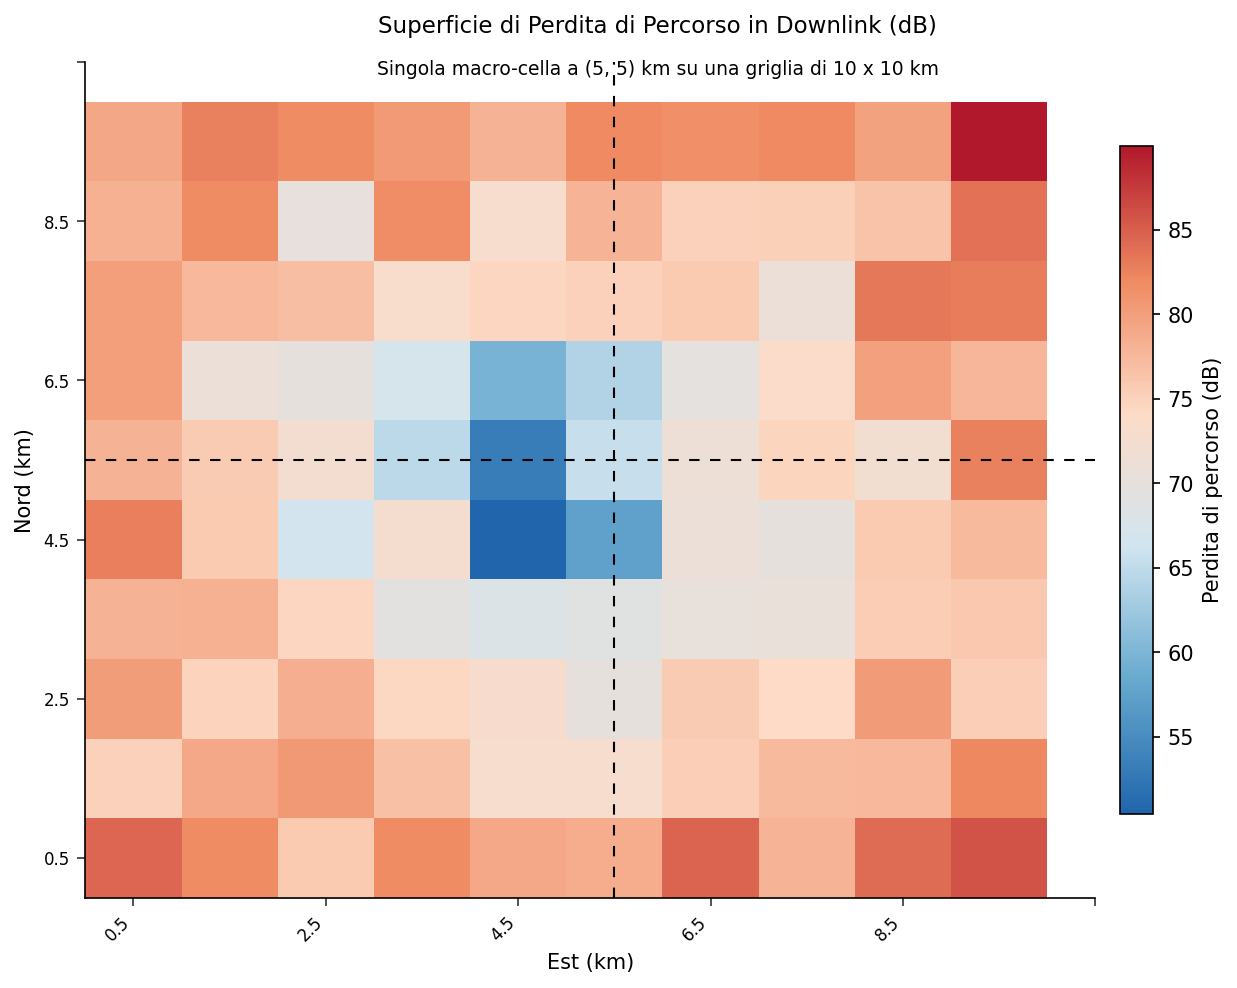

In [4]:
ODS GRAPHICS ON;
TITOLO "Superficie di Perdita di Percorso in Downlink (dB)";
title2 "Singola macro-cella a (5, 5) km su una griglia di 10 x 10 km";

PROCEDURA SGPLOT DATI=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / TITOLO="Perdita di percorso (dB)";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) ETICHETTA="Est (km)";
   YAXIS VALUES=(0 2 4 6 8 10) ETICHETTA="Nord (km)";
ESEGUIRE;

TITOLO; title2;

## Passo 5 — Ripartizione delle classi di copertura

Una slide di briefing vuole anche la ripartizione principale: quale frazione dell'impronta è Forte, Utilizzabile o Debole. Un `VBAR` della classificazione `zone` mostra questo a colpo d'occhio e si accompagna alla superficie di contorno sopra.

                                         Ripartizione delle Classi di Copertura                                         




NOTE: Option TITLE changed to Ripartizione delle Classi di Copertura.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


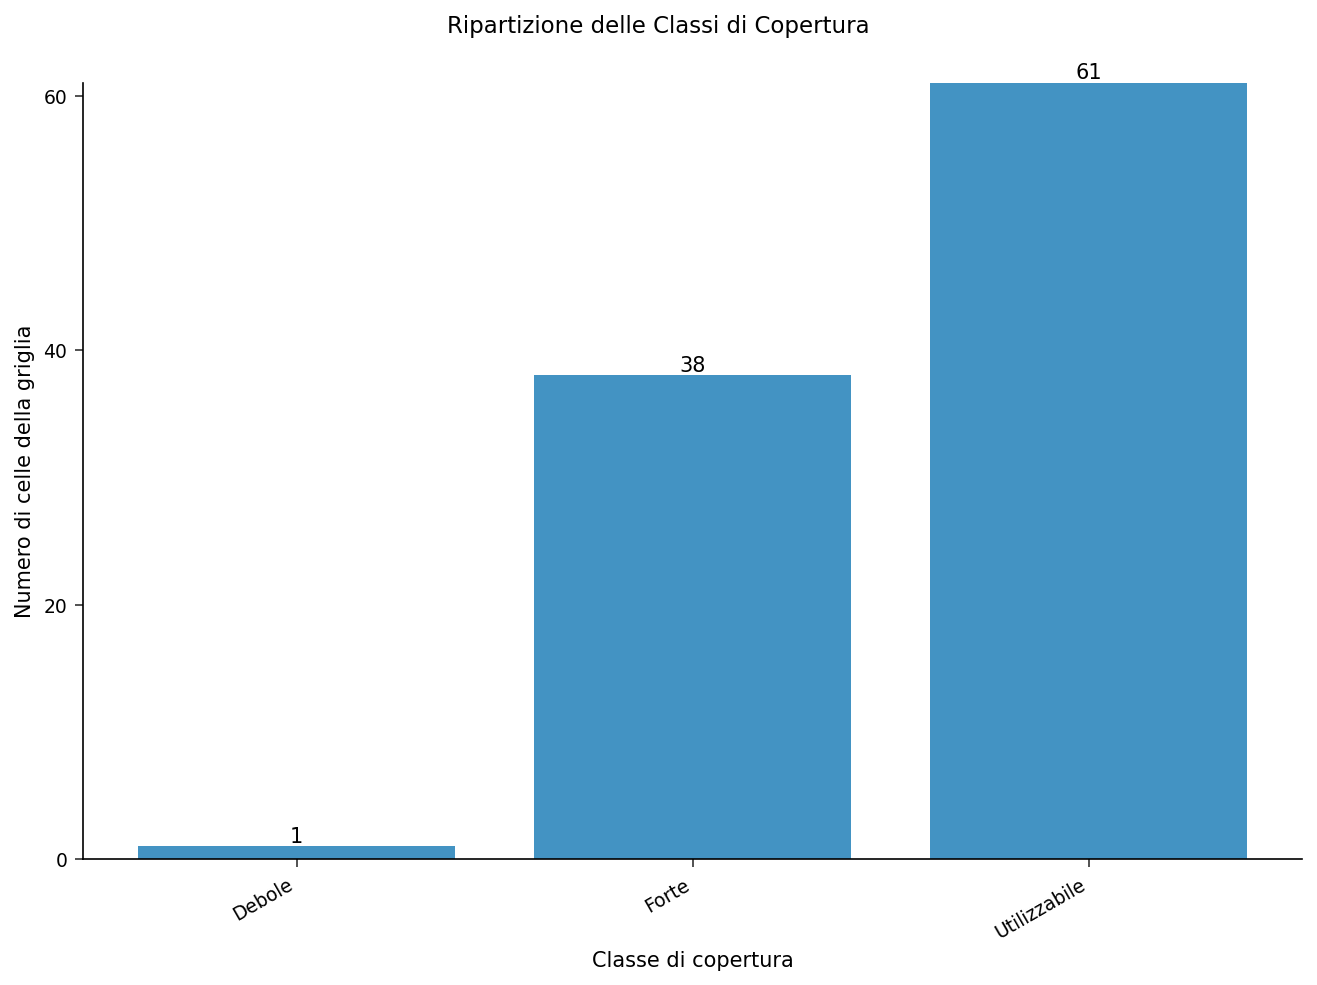

In [5]:
TITOLO "Ripartizione delle Classi di Copertura";

PROCEDURA SGPLOT DATI=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS ETICHETTA="Classe di copertura";
   YAXIS ETICHETTA="Numero di celle della griglia" VALUES=(0 20 40 60);
ESEGUIRE;

TITOLO;

## Interpretazione dei risultati

La superficie di contorno conferma la fisica di propagazione attesa. La perdita di percorso è più bassa in uno stretto **bacino blu attorno alla torre a (5, 5) km** — la zona Forte dove il segnale ricevuto è migliore — e cresce con il log-distanza verso gli angoli. Poiché abbiamo iniettato uno shadow fading log-normale, le bande non sono cerchi concentrici; le celle rosse frastagliate lungo il bordo sono il margine soggetto a shadow fading.

Il dato azionabile è la **singola cella Debole a (9.5, 9.5) km (89.97 dB)**, l'angolo diagonalmente opposto alla torre e l'unico punto che supera la soglia di progetto di 88 dB. Con **61 celle su 100 Utilizzabili e solo 1 Debole**, questa macro-cella copre bene la sua area di servizio; l'unico buco giustificherebbe un **infill con small-cell o un re-tilt del settore verso l'angolo nord-est** solo se si sovrapponesse a un hotspot di domanda noto. La superficie di contorno è il riepilogo pronto per il briefing; il grafico a barre delle classi di copertura fornisce il numero singolo che un capacity planner riporta al livello superiore.